# Sea-ice thickness and snow-depth inversion with a 1D multi-output GP

This notebook adapts `MultioutputGPPlayground.ipynb` to the dissertation's
two-equation, two-unknown proof of concept.

The latent fields are sea-ice thickness $H_i(x)$ and snow depth $H_s(x)$. The
observations are collocated CryoSat-2 radar freeboard and ICESat-2 laser
freeboard:

$$
\begin{bmatrix}F_r^{cs} \\ F_l^{is}\end{bmatrix}
=
\underbrace{\begin{bmatrix}A & B_{cs} \\ A & B_{is}\end{bmatrix}}_{H}
\begin{bmatrix}H_i \\ H_s\end{bmatrix}+\epsilon,
\qquad \epsilon\sim\mathcal N(0,R).
$$

This is a controlled synthetic experiment. The physical constants below are
explicit, editable assumptions and must later be aligned with the dissertation
source paper and supervisor guidance before interpreting real data.


## Environment

Run this notebook in a dedicated environment containing compatible versions of
TensorFlow, GPflow, NumPy, Matplotlib and `check_shapes`. Do not run an
unversioned `pip install` cell inside a shared UCL environment. First record the
versions printed below so the experiment can be reproduced.


In [1]:
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
import gpflow
from gpflow.likelihoods import Gaussian, Likelihood
from gpflow.models import GPR, GPModel
from gpflow.utilities.parameter_or_function import (
    ConstantOrFunction,
    ParameterOrFunction,
    evaluate_parameter_or_function,
    prepare_parameter_or_function,
)
from gpflow.models.util import data_input_to_tensor
from gpflow.utilities import add_likelihood_noise_cov
from gpflow.logdensities import multivariate_normal
from gpflow.mean_functions import MeanFunction, Zero
from check_shapes import check_shapes, inherit_check_shapes
import tensorflow as tf
from typing import Optional
from copy import copy
import sys

print('Python:', sys.version)
print('TensorFlow:', tf.__version__)
print('GPflow:', gpflow.__version__)


Python: 3.12.13 (main, Mar  3 2026, 15:35:03) [Clang 21.1.4 ]
TensorFlow: 2.16.2
GPflow: 2.11.1


## Multi-output likelihood and exact GP

These classes come from the supervisor notebook. The likelihood evaluates the
data in observation space, $y=Hf+\epsilon$, while `predict_f` returns the two
latent physical fields.


In [2]:
class LinearModelLikelihood(Likelihood):
    """
    Implements Gaussian likelihood of form y = Hx + noise
    """
    def __init__(self, input_dim, variance, H):
        observation_dim, latent_dim = H.shape
        super().__init__(input_dim=input_dim, latent_dim=latent_dim, observation_dim=observation_dim)

        if isinstance(variance, (int, float)):
            variance = variance*tf.eye(observation_dim, dtype=tf.float64)

        assert variance.shape == (observation_dim, observation_dim)

        self.variance = prepare_parameter_or_function(variance) # Converts variance to gpflow parameter
        self.H = H

    @staticmethod
    @check_shapes(
        "x: [broadcast shape..., input_dim]",
        "mu: [broadcast shape..., P]",
        "cov: [broadcast shape..., P, P]",
        "return: [shape...]",
    )
    def multivariate_gaussian_log_density(x, mu, cov) -> tf.Tensor:
        P = mu.shape[-1]
        diff = tf.expand_dims(mu-x, axis=-1) # (..., P, 1)
        shape = tf.concat([tf.shape(mu)[:-1], [P, P]], axis=0)
        cov_broadcast = tf.broadcast_to(cov, shape) # (..., P, P)
        out = - (P/2) * np.log(2 * np.pi) \
              - 0.5 * tf.linalg.logdet(cov) \
              - 0.5 * tf.linalg.matmul(diff, tf.linalg.solve(cov_broadcast, diff), transpose_a=True) # (..., 1, 1)
        return tf.reduce_sum(out, [-1,-2]) # (..., 1, 1) -> (...)

    @check_shapes(
        "X: [batch..., N, D]",
        "return: [batch..., N, P, P]",
    )
    def variance_at(self, X) -> tf.Tensor:
        variance = self.variance
        P = variance.shape[0]
        shape = tf.concat([tf.shape(X)[:-1], [P, P]], 0)
        return tf.broadcast_to(variance, shape)

    @inherit_check_shapes
    def _log_prob(self, X, F, Y) -> tf.Tensor:
        HF = tf.linalg.matvec(self.H, F)
        # return gpflow.logdensities.gaussian(Y, HF, self.variance) # Note: only deals with scalar y
        return self.multivariate_gaussian_log_density(Y, HF, self.variance)

    @inherit_check_shapes
    def _conditional_mean(self, X, F) -> tf.Tensor:
        HF = tf.linalg.matvec(self.H, F)
        return tf.identity(HF)

    @inherit_check_shapes
    def _conditional_variance(self, X, F) -> tf.Tensor:
        shape = (tf.shape(F)[0], self.observation_dim)
        return tf.broadcast_to(self.variance, shape)

    @check_shapes(
        "X: [broadcast batch..., input_dim]",
        "Fmu: [broadcast batch..., latent_dim]",
        "Fcov: [broadcast batch..., latent_dim, latent_dim]",
        "return[0]: [batch..., observation_dim]",
        "return[1]: [batch..., observation_dim, observation_dim]",
    )
    def _predict_mean_and_var(self, X, Fmu, Fcov) -> tf.Tensor:
        HFmu = tf.linalg.matvec(self.H, Fmu)
        HFcovHt = self.H @ Fcov @ tf.transpose(self.H)
        return tf.identity(HFmu), HFcovHt + self.variance

    def predict_mean_and_var(self, X, Fmu, Fcov):
        return self._predict_mean_and_var(X, Fmu, Fcov)

    @check_shapes(
        "X: [broadcast batch..., input_dim]",
        "Fmu: [broadcast batch..., latent_dim]",
        "Fcov: [broadcast batch..., latent_dim, latent_dim]",
        "return: [batch...]",
    )
    def _predict_log_density(self, X, Fmu, Fcov, Y) -> tf.Tensor:
        HFmu = tf.linalg.matvec(self.H, Fmu) # Shape (..., P)
        HFcovHt = self.H @ Fcov @ tf.transpose(self.H) # Shape (..., P, P)
        return self.multivariate_gaussian_log_density(Y, HFmu, HFcovHt + self.variance)

    def predict_log_density(self, X, Fmu, Fcov, Y):
        return self._predict_log_density(X, Fmu, Fcov, Y)

    @check_shapes(
        "X: [broadcast batch..., input_dim]",
        "Fmu: [broadcast batch..., latent_dim]",
        "Fcov: [broadcast batch..., latent_dim, latent_dim]",
        "return: [batch...]",
    )
    def _variational_expectations(self, X, Fmu, Fcov, Y) -> tf.Tensor:
        HFmu = tf.linalg.matvec(self.H, Fmu) # Shape (..., P)
        HFcovHt = self.H @ Fcov @ tf.transpose(self.H) # Shape (..., P, P)
        covariance = self.variance # (P, P)
        shape = tf.concat([tf.shape(HFmu)[:-1], tf.shape(covariance)], axis=0)
        cov_broadcast = tf.broadcast_to(covariance, shape) # (..., P, P)
        P = self.observation_dim
        diff = tf.expand_dims(Y-HFmu, axis=-1) # Shape (..., P, 1)
        output = - (P/2) * np.log(2 * np.pi) \
                 - 0.5 * tf.linalg.logdet(covariance) \
                 - 0.5 * tf.squeeze(tf.matmul(diff, tf.linalg.solve(cov_broadcast, diff), transpose_a=True)) \
                 - 0.5 * tf.linalg.trace(tf.linalg.solve(cov_broadcast, HFcovHt))
        return output

    def variational_expectations(self, X, Fmu, Fcov, Y):
        return self._variational_expectations(X, Fmu, Fcov, Y)


class MultioutputGPR(GPR):
    """
    Module for Gaussian process regression in the multi-output setting
    In the comments we use the following notations:
    M: Training size, N: Test Size, L: Latent GP dimension, P: Observation dimension
    """
    def __init__(self,
                 data,
                 kernel,
                 num_latent_gps,
                 mean_function = None,
                 noise_variance = None,
                 likelihood: LinearModelLikelihood = None):
        assert (noise_variance is None) or (
            likelihood is None
        ), "Cannot set both `noise_variance` and `likelihood`."
        if likelihood is None:
            if noise_variance is None:
                noise_variance = 1.0
            likelihood = gpflow.likelihoods.Gaussian(noise_variance)
        _, Y_data = data

        GPModel.__init__(self, kernel, likelihood, mean_function, num_latent_gps=num_latent_gps)

        self.data = data_input_to_tensor(data)

        if mean_function is None:
            self.mean_function = Zero(output_dim=Y_data.shape[-1])

    @staticmethod
    @check_shapes(
        "K: [batch..., N, N, P, P]",
        "return: [batch..., N, N, P, P]",
    ) # TODO: Simplify by taking shape [N, P, N, P] instead
    def add_likelihood_noise_cov(K, likelihood: LinearModelLikelihood):
        R = likelihood.variance # Shape (P, P)
        N, P = K.shape[-3], K.shape[-1]
        # Construct a block-diagonal matrix of R's to add to K
        R_op = tf.linalg.LinearOperatorFullMatrix(R)
        R_op_diag = tf.linalg.LinearOperatorBlockDiag([R_op for _ in range(N)]) # Shape (N*P, N*P)
        # Reshape K to tensor of hape (..., N*P, N*P)
        axis_indices = [i for i in range(len(K.shape))]
        leading_indices, tensor_indices = axis_indices[:-4], axis_indices[-4:]
        tensor_indices_permuted = [tensor_indices[0], tensor_indices[2], tensor_indices[1], tensor_indices[3]]
        K = tf.transpose(K, leading_indices+tensor_indices_permuted) # Shape (..., N, P, N, P)
        leading_dims = K.shape[:-4]
        K = tf.reshape(K, leading_dims+[N*P, N*P]) # Shape (..., N*P, N*P)
        # Add R's to the diagonal of K and reshape
        KnR = R_op_diag.add_to_tensor(K) # Shape (..., N*P, N*P)
        KnR = tf.reshape(KnR, leading_dims+[N, P, N, P]) # Shape (..., N, P, N, P)
        return tf.transpose(KnR, leading_indices+tensor_indices_permuted) # Shape (..., N, N, P, P)

    @check_shapes(
        "Kmn: [M, L, N, L]",
        "Kmm: [M, L, M, L]",
        "Knn: [N, L, N, L] if full_cov",
        "Knn: [N, L, L] if not full_cov",
        "f: [M, P]",
        "return[0]: [N, L]",
        "return[1]: [N, L, N, L] if full_cov",
        "return[1]: [N, L, L] if not full_cov",
    )
    def multioutput_conditional(self,
                                Kmn: tf.Tensor, # Shape (M, L, N, L)
                                Kmm: tf.Tensor, # Shape (M, L, M, L)
                                Knn: tf.Tensor, # Shape (N, L, N, L)
                                f: tf.Tensor, # Shape (M, P)
                                *,
                                full_cov=False):

        Kmn = tf.transpose(Kmn, [0,2,1,3]) # Shape (M, N, L, L)
        Kmm = tf.transpose(Kmm, [0,2,1,3]) # Shape (M, M, L, L)
        H = self.likelihood.H

        HKmmHt = H @ Kmm @ tf.transpose(H) # Shape (M, M, P, P)
        HKmn = H @ Kmn # Shape (M, N, P, L)
        ks = self.add_likelihood_noise_cov(HKmmHt, self.likelihood) # Shape (M, M, P, P)
        ks = tf.transpose(ks, [0,2,1,3]) # Shape (M, P, M, P)
        N, P, M, _ = ks.shape
        ks = tf.reshape(ks, (M*P, M*P)) # Reshape to size (MP, MP)
        Lm = tf.linalg.cholesky(ks) # Shape (MP, MP)

        # Compute the projection matrix A
        HKmn = tf.transpose(HKmn, [0,2,1,3]) # Shape (M, P, N, L)
        M, P, N, L = HKmn.shape
        HKmn = tf.reshape(HKmn, (M*P, N*L)) # Reshape to size (MP, NL)
        A = tf.linalg.triangular_solve(Lm, HKmn, lower=True)  # Shape (MP, NL)

        # Compute conditional covariance
        if full_cov:
            Knn = tf.reshape(Knn, (N*L, N*L))
            fvar = Knn - tf.linalg.matmul(A, A, transpose_a=True) # Shape (NL, NL)
            fvar = tf.reshape(fvar, (N, L, N, L))
        else:
            def square(tensor):
                """Input is a tensor of shape (M, P, L) """
                tensor = tf.reshape(tensor, (M*P, L)) # Reshape to size (MP, L)
                return tf.linalg.matmul(tensor, tensor, transpose_a=True) # Shape (L, L)

            A = tf.reshape(A, (M, P, N, L))
            AtA_diag = tf.stack([square(A[:,:,n,:]) for n in range(N)], 0) # Shape (N, L, L)
            fvar = Knn - AtA_diag
            A = tf.reshape(A, (M*P, N*L))

        # Compute conditional mean
        f = tf.reshape(f, (M*P,1)) # Shape (MP, 1)
        A = tf.linalg.triangular_solve(tf.linalg.adjoint(Lm), A, lower=False) # Shape (MP, NL)
        fmean = tf.linalg.matmul(A, f, transpose_a=True) # Shape (NL, 1)
        fmean = tf.reshape(fmean, (N,L)) # Shape (N, L)

        return fmean, fvar

    @inherit_check_shapes
    def log_marginal_likelihood(self) -> tf.Tensor:
        X, Y = self.data
        H = self.likelihood.H
        K = self.kernel(X, full_cov=True, full_output_cov=True) # Shape (N, L, N, L)
        K = tf.transpose(K, [0,2,1,3]) # Shape (N, N, L, L)
        HKHt = H @ K @ tf.transpose(H) # Shape (N, N, P, P)
        ks = self.add_likelihood_noise_cov(HKHt, self.likelihood) # Shape (N, N, P, P)
        ks = tf.transpose(ks, [0,2,1,3]) # Shape (N, P, N, P)
        N, P = ks.shape[:2]
        ks = tf.reshape(ks, (N*P, N*P)) # Shape (NP, NP)
        L = tf.linalg.cholesky(ks)
        m = self.mean_function(X)
        log_prob = multivariate_normal(tf.reshape(Y, (N*P, 1)),
                                       tf.reshape(m, (N*P, 1)),
                                       L
                    )
        return tf.reduce_sum(log_prob)

    @inherit_check_shapes
    def predict_f(
        self, Xnew, full_cov: bool = False, full_output_cov: bool = False
    ):
        X, Y = self.data
        err = Y - self.mean_function(X) # TODO: Handle multivariate mean properly. Shape (M, P)

        kmm = self.kernel(X, full_cov=True, full_output_cov=True) # Shape (M, L, M, L)
        knn = self.kernel(Xnew, full_cov=full_cov, full_output_cov=True) # Shape (N, L, N, L)
        kmn = self.kernel(X, Xnew, full_cov=True, full_output_cov=True) # Shape (M, L, N, L)

        f_mean_zero, f_var = self.multioutput_conditional(
            kmn, kmm, knn, err, full_cov=full_cov
        )  # [N, P], [N, P] or [P, N, N]

        f_mean = f_mean_zero + self.mean_function(Xnew)

        if not full_output_cov:
            f_var = tf.linalg.diag_part(f_var)

        return f_mean, f_var

## 1. Physical assumptions and forward matrix

For this first experiment the penetration factors are fixed. The matrix
determinant and condition number are reported because a nearly singular $H$
means that ice thickness and snow depth cannot be reliably separated, even if
the reconstructed freeboards look accurate.


In [3]:
# All lengths are in metres. These are illustrative baseline assumptions.
rho_w = 1024.0
rho_i = 915.0
rho_s = 300.0

alpha_cs = 1.0   # initial full-penetration assumption
alpha_is = 0.0   # laser return at the snow surface

# Illustrative dry-snow dielectric relation; verify against the dissertation source.
rho_s_g_cm3 = rho_s / 1000.0
epsilon_s = (1.0 + 0.51 * rho_s_g_cm3) ** 3
c_over_cs = np.sqrt(epsilon_s)

A = (rho_w - rho_i) / rho_w
B_cs = 1.0 - alpha_cs * c_over_cs - rho_s / rho_w
B_is = 1.0 - alpha_is * c_over_cs - rho_s / rho_w

H = np.array([[A, B_cs],
              [A, B_is]], dtype=np.float64)

sigma_cs = 0.03
sigma_is = 0.02
R = np.diag([sigma_cs**2, sigma_is**2]).astype(np.float64)

print('H =\n', H)
print('R =\n', R)
print('det(H) =', np.linalg.det(H))
print('condition number(H) =', np.linalg.cond(H))

if np.linalg.cond(H) > 30:
    print('WARNING: the forward matrix is poorly conditioned.')


H =
 [[ 0.10644531 -0.53103522]
 [ 0.10644531  0.70703125]]
R =
 [[0.0009 0.    ]
 [0.     0.0004]]
det(H) = 0.1317863719880586
condition number(H) = 5.936528612682016


## 2. Synthetic 1D sea-ice fields and satellite observations


In [4]:
rng = np.random.default_rng(7)

# A 100 km synthetic along-track domain, evaluated every kilometre.
xs = np.arange(0.0, 100.0, 1.0, dtype=np.float64)[:, None]

# Positive, interpretable ground-truth fields.
Hi_true = 2.00 + 0.30*np.sin(xs[:, 0]/13.0) + 0.12*np.exp(-((xs[:, 0]-65.0)/10.0)**2)
Hs_true = 0.25 + 0.055*np.cos(xs[:, 0]/10.0) + 0.020*np.sin(xs[:, 0]/4.5)
f_true = np.column_stack([Hi_true, Hs_true])

# Observe every 2 km and add sensor-specific Gaussian noise.
step = 2
x_train = xs[::step]
f_train_true = f_true[::step]
y_train_clean = f_train_true @ H.T
y_train = y_train_clean + rng.multivariate_normal(
    mean=np.zeros(2), cov=R, size=len(x_train)
)

print('latent truth shape:', f_true.shape)
print('training X shape:', x_train.shape)
print('observations Y shape:', y_train.shape)
print('Hi range:', (Hi_true.min(), Hi_true.max()))
print('Hs range:', (Hs_true.min(), Hs_true.max()))


latent truth shape: (100, 2)
training X shape: (50, 1)
observations Y shape: (50, 2)
Hi range: (1.777616406487291, 2.299843183076052)
Hs range: (0.1926350708453422, 0.3248043721149852)


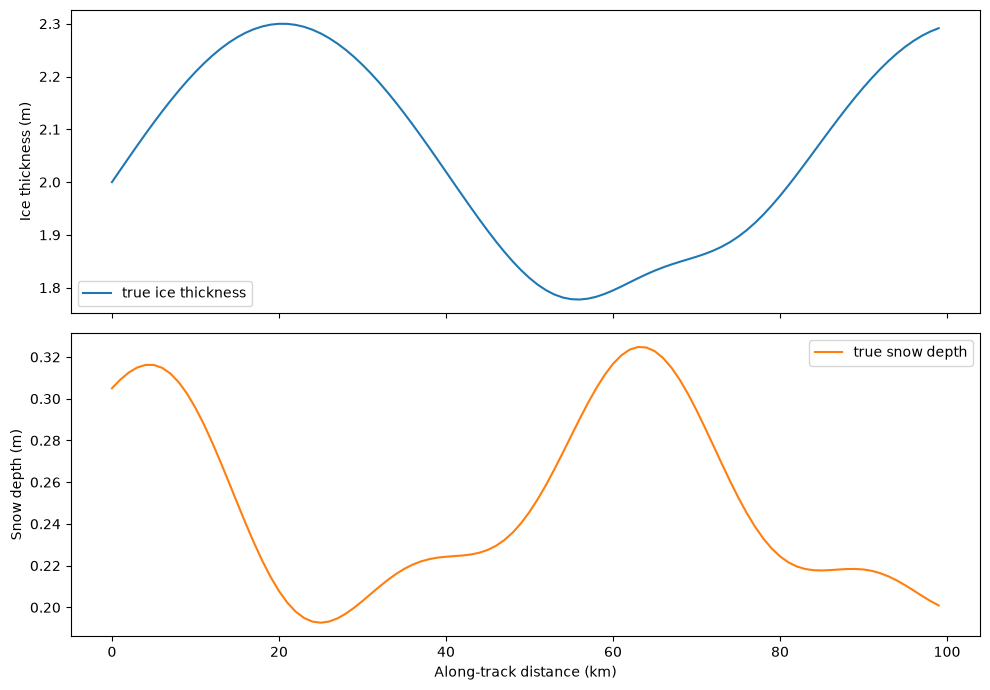

In [5]:
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axs[0].plot(xs, Hi_true, label='true ice thickness')
axs[0].set_ylabel('Ice thickness (m)')
axs[0].legend()

axs[1].plot(xs, Hs_true, color='C1', label='true snow depth')
axs[1].set_xlabel('Along-track distance (km)')
axs[1].set_ylabel('Snow depth (m)')
axs[1].legend()
plt.tight_layout()


## 3. Pointwise inversion baseline

This deliberately ignores spatial correlation. It is the essential baseline
for checking the equations, units and noise amplification before fitting a GP.


In [6]:
f_point = np.linalg.solve(H, y_train.T).T

def metrics(truth, prediction):
    error = prediction - truth
    return {
        'RMSE': float(np.sqrt(np.mean(error**2))),
        'MAE': float(np.mean(np.abs(error))),
        'bias': float(np.mean(error)),
    }

point_metrics = {
    'Hi': metrics(f_train_true[:, 0], f_point[:, 0]),
    'Hs': metrics(f_train_true[:, 1], f_point[:, 1]),
}
print('Pointwise inversion:', point_metrics)
print('Negative Hi estimates:', int(np.sum(f_point[:, 0] < 0)))
print('Negative Hs estimates:', int(np.sum(f_point[:, 1] < 0)))


Pointwise inversion: {'Hi': {'RMSE': 0.17149952379868888, 'MAE': 0.13098304013168835, 'bias': -0.045898219630682566}, 'Hs': {'RMSE': 0.02431991700027541, 'MAE': 0.019372466357466922, 'bias': 0.0034717388447739785}}
Negative Hi estimates: 0
Negative Hs estimates: 0


## 4. Exact multi-output GP inversion

The model operates on deviations from physically interpretable baseline means.
This keeps the inherited exact-GP implementation in its tested zero-mean form.
The output mixing matrix is fixed for this first smoke test; later experiments
must compare fixed, independent and trainable output correlations.


In [7]:
latent_baseline = np.array([2.0, 0.25], dtype=np.float64)
observation_baseline = H @ latent_baseline
y_centered = y_train - observation_baseline

# Fresh inference kernels: do not reuse kernels that generated the truth.
kern_hi = gpflow.kernels.Matern52(lengthscales=15.0, variance=1.0)
kern_hs = gpflow.kernels.Matern52(lengthscales=10.0, variance=1.0)
W_prior = np.array([[0.35, 0.00],
                    [0.00, 0.07]], dtype=np.float64)

kernel = gpflow.kernels.LinearCoregionalization(
    [kern_hi, kern_hs], W=W_prior
)
likelihood = LinearModelLikelihood(input_dim=1, variance=R, H=H)
model = MultioutputGPR(
    data=(x_train, y_centered),
    kernel=kernel,
    likelihood=likelihood,
    num_latent_gps=2,
)

gpflow.utilities.set_trainable(model.kernel.W, False)
gpflow.utilities.set_trainable(model.likelihood.variance, False)
gpflow.utilities.print_summary(model)


╒═══════════════════════════════════════════════╤═══════════╤═════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════╕
│ name                                          │ class     │ transform   │ prior   │ trainable   │ shape   │ dtype   │ value           │
╞═══════════════════════════════════════════════╪═══════════╪═════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════╡
│ MultioutputGPR.kernel.kernels[0].variance     │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │ 1.0             │
├───────────────────────────────────────────────┼───────────┼─────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────┤
│ MultioutputGPR.kernel.kernels[0].lengthscales │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │ 15.0            │
├───────────────────────────────────────────────┼───────────┼─────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────┤
│ MultioutputGPR.kernel.kernels[1]

In [8]:
opt = gpflow.optimizers.Scipy()
opt_logs = opt.minimize(
    model.training_loss,
    model.trainable_variables,
    options=dict(maxiter=2000),
)
print(opt_logs)


  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -225.0036190726102
        x: [ 1.179e+01 -2.495e+00  1.269e+01 -1.159e+00]
      nit: 17
      jac: [-1.264e-08  9.661e-06  2.045e-06 -5.372e-06]
     nfev: 20
     njev: 20
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>


2026-08-08 20:09:56.753138: W external/local_tsl/tsl/platform/profile_utils/cpu_utils.cc:145] Failed to get CPU frequency: 0 Hz


## 5. Latent-field recovery, uncertainty and observation reconstruction


In [9]:
f_dev_mean, f_dev_var = model.predict_f(xs)
f_mean = f_dev_mean.numpy() + latent_baseline
f_var = f_dev_var.numpy()
f_std = np.sqrt(np.maximum(f_var, 0.0))

gp_metrics = {
    'Hi': metrics(Hi_true, f_mean[:, 0]),
    'Hs': metrics(Hs_true, f_mean[:, 1]),
}

y_reconstructed = f_mean @ H.T
y_true_full = f_true @ H.T
freeboard_metrics = {
    'CS2': metrics(y_true_full[:, 0], y_reconstructed[:, 0]),
    'IS2': metrics(y_true_full[:, 1], y_reconstructed[:, 1]),
}

coverage = {
    'Hi_95pct': float(np.mean(np.abs(Hi_true-f_mean[:, 0]) <= 1.96*f_std[:, 0])),
    'Hs_95pct': float(np.mean(np.abs(Hs_true-f_mean[:, 1]) <= 1.96*f_std[:, 1])),
}

print('Pointwise metrics:', point_metrics)
print('GP latent metrics:', gp_metrics)
print('Reconstructed freeboard metrics:', freeboard_metrics)
print('Empirical interval coverage:', coverage)


Pointwise metrics: {'Hi': {'RMSE': 0.17149952379868888, 'MAE': 0.13098304013168835, 'bias': -0.045898219630682566}, 'Hs': {'RMSE': 0.02431991700027541, 'MAE': 0.019372466357466922, 'bias': 0.0034717388447739785}}
GP latent metrics: {'Hi': {'RMSE': 0.11835281932621965, 'MAE': 0.09415553433590641, 'bias': -0.048766381867429966}, 'Hs': {'RMSE': 0.015577935307636364, 'MAE': 0.011874047005080147, 'bias': 0.0035843590370397914}}
Reconstructed freeboard metrics: {'CS2': {'RMSE': 0.020087953338930722, 'MAE': 0.015589192388711147, 'bias': -0.007094373636833247}, 'IS2': {'RMSE': 0.006722024913609508, 'MAE': 0.005668256721570326, 'bias': -0.0026566989069658747}}
Empirical interval coverage: {'Hi_95pct': 0.69, 'Hs_95pct': 0.81}


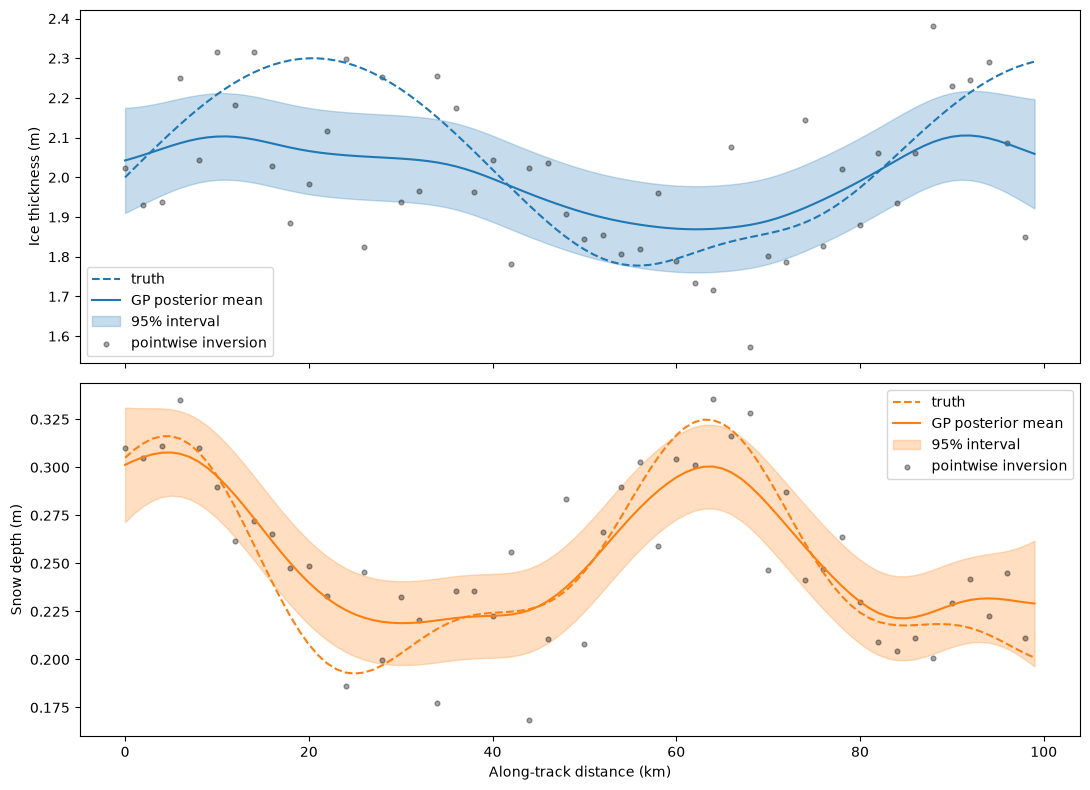

In [10]:
fig, axs = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
labels = [('Ice thickness', 'm'), ('Snow depth', 'm')]
truths = [Hi_true, Hs_true]

for j, ax in enumerate(axs):
    ax.plot(xs[:, 0], truths[j], '--', color=f'C{j}', label='truth')
    ax.plot(xs[:, 0], f_mean[:, j], color=f'C{j}', label='GP posterior mean')
    ax.fill_between(
        xs[:, 0],
        f_mean[:, j] - 1.96*f_std[:, j],
        f_mean[:, j] + 1.96*f_std[:, j],
        color=f'C{j}', alpha=0.25, label='95% interval'
    )
    ax.scatter(x_train[:, 0], f_point[:, j], s=12, color='black', alpha=0.35,
               label='pointwise inversion')
    ax.set_ylabel(f'{labels[j][0]} ({labels[j][1]})')
    ax.legend(loc='best')

axs[-1].set_xlabel('Along-track distance (km)')
plt.tight_layout()


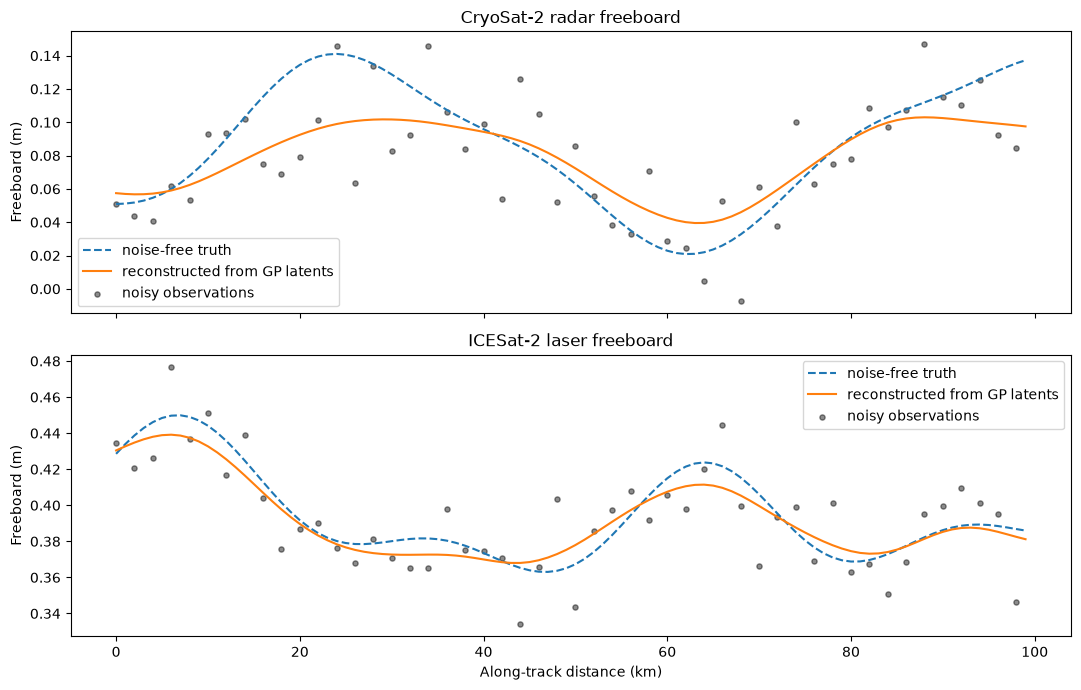

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
sensor_names = ['CryoSat-2 radar freeboard', 'ICESat-2 laser freeboard']
for j, ax in enumerate(axs):
    ax.plot(xs[:, 0], y_true_full[:, j], '--', label='noise-free truth')
    ax.plot(xs[:, 0], y_reconstructed[:, j], label='reconstructed from GP latents')
    ax.scatter(x_train[:, 0], y_train[:, j], s=14, color='black', alpha=0.45,
               label='noisy observations')
    ax.set_ylabel('Freeboard (m)')
    ax.set_title(sensor_names[j])
    ax.legend(loc='best')
axs[-1].set_xlabel('Along-track distance (km)')
plt.tight_layout()


## 6. Required follow-up experiments

Do not move to real CRYO2ICE data until the following controlled tests have
been recorded:

1. low, medium and high observation noise;
2. dense, sparse and gapped sampling;
3. correct versus misspecified densities and penetration factors;
4. fixed diagonal, fixed correlated and trainable coregionalisation matrices;
5. condition number of the forward matrix in every physical scenario;
6. latent RMSE, freeboard RMSE, bias and 95% coverage;
7. exact GP runtime compared with the later SVGP and DRF baselines.

The next engineering task is a separate DRF smoke-test notebook using this
same synthetic dataset. This notebook should remain the GP reference model.
